# Shear accuracy: selection bias analysis

Investigates how galaxy properties (magnitude, Sersic index, half-light radius) affect the BATSim vs GalSim multiplicative bias comparison.

Uses **auto-detection** (FPFS peak-finding) to match the original measurement approach, then reverse-maps each detected source back to its input galaxy using the known regular grid layout.

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import galsim
import batsim
import anacal
import numpy as np
import matplotlib.pyplot as plt
import pickle

from tqdm import tqdm
from importlib import reload
reload(batsim)

<module 'batsim' from '/home/nep151/github/BATSim/src/batsim/__init__.py'>

In [2]:
def measure_shear(gal_array, psf_array, npix, pixel_scale, noise_variance, noise_array, detection):
    """
    Measure shear using the FPFS estimator via anacal.

    Parameters
    ----------
    gal_array : np.ndarray
        2D galaxy image array.
    psf_array : np.ndarray
        2D PSF image array.
    npix : int
        Individual galaxy stamp size in pixels, used for shapelet basis operations.
    pixel_scale : float
        Pixel scale in arcsec/pixel.
    noise_variance : float
        Noise variance of the image. A minimum floor of 0.23 is applied internally.
    noise_array : np.ndarray or None
        2D noise image array, or None if not available.
    detection : np.ndarray or None
        Structured array with fields ('y', 'x') giving pre-specified detection
        positions. If None, FPFS auto-detection is run.

    Returns
    -------
    np.ndarray
        Structured array containing per-galaxy FPFS measurements, including
        fields such as 'fpfs_w', 'fpfs_e1', 'fpfs_de1_dg1', 'fpfs_dw_dg1'.
    """
    fpfs_config = anacal.fpfs.FpfsConfig(
        sigma_shapelets=0.52,
        sigma_shapelets2=0.45,
        npix=npix
    )
    catalog = anacal.fpfs.process_image(
        fpfs_config=fpfs_config,
        mag_zero=30.0,
        gal_array=gal_array,
        psf_array=psf_array,
        pixel_scale=pixel_scale,
        noise_variance=max(noise_variance, 0.23),
        noise_array=noise_array,
        detection=detection,
    )
    return catalog


def jackknife_over_tiles(E_tiles, R_tiles, lens_shear):
    """
    Estimate multiplicative bias and its uncertainty using tile-based jackknife.

    Parameters
    ----------
    E_tiles : array_like
        Per-tile sums of the weighted ellipticity (fpfs_w * fpfs_e1).
    R_tiles : array_like
        Per-tile sums of the shear response.
    lens_shear : float
        True input shear g1 used to compute the multiplicative bias m = g1_hat/g1 - 1.

    Returns
    -------
    dict
        Dictionary with keys:
        'g1'      : float, estimated shear.
        'g1_err'  : float, jackknife standard error on g1.
        'm'       : float, multiplicative bias.
        'm_err'   : float, jackknife standard error on m.
        'E_tiles' : np.ndarray, input E sums per tile.
        'R_tiles' : np.ndarray, input R sums per tile.
        'g1_loo'  : np.ndarray, leave-one-out g1 estimates.
        'm_loo'   : np.ndarray, leave-one-out m estimates.
    """
    E_tiles = np.asarray(E_tiles)
    R_tiles = np.asarray(R_tiles)
    E_tot = E_tiles.sum()
    R_tot = R_tiles.sum()
    g1 = E_tot / R_tot
    m  = g1 / lens_shear - 1
    n = len(E_tiles)
    g1_loo = (E_tot - E_tiles) / (R_tot - R_tiles)
    m_loo  = g1_loo / lens_shear - 1
    g1_err = np.sqrt((n - 1) / n * np.sum((g1_loo - g1_loo.mean()) ** 2))
    m_err  = np.sqrt((n - 1) / n * np.sum((m_loo  - m_loo.mean())  ** 2))
    return {"g1": g1, "g1_err": g1_err, "m": m, "m_err": m_err,
            "E_tiles": E_tiles, "R_tiles": R_tiles,
            "g1_loo": g1_loo, "m_loo": m_loo}

In [3]:
np.random.seed(14)

cosmos = galsim.COSMOSCatalog()
print(f'Catalog size: {len(cosmos)}')

# Must match the parameters used to generate the saved stamps
scale          = 0.2
nn             = 96
lens_shear     = 0.02
n_rot          = 4
n_gal_stamp    = 1600
tiles_per_side = 40
tile_size      = int(nn * np.sqrt(n_rot))           # 192
stamp_size     = int(nn * np.sqrt(n_rot * n_gal_stamp))  # 7680

n_stamps   = int(np.ceil(len(cosmos) / n_gal_stamp))
all_inds   = np.arange(len(cosmos))
stamp_inds = np.array_split(all_inds, n_stamps)
print(f'Number of stamps: {n_stamps}')

psf       = galsim.Moffat(beta=3.5, fwhm=0.7)
psf_array = psf.drawImage(nx=nn, ny=nn, scale=scale).array

Catalog size: 81499
Number of stamps: 51


In [4]:
galsim_stamps = []
batsim_stamps = []

for i in tqdm(range(n_stamps)):
    gs_file = os.path.join('COSMOS_lensed', f'galsim_stamp_{i}_{stamp_size}x{stamp_size}.fits')
    bt_file = os.path.join('COSMOS_lensed', f'batsim_stamp_{i}_{stamp_size}x{stamp_size}.fits')
    galsim_stamps.append(galsim.fits.read(file_name=gs_file))
    batsim_stamps.append(galsim.fits.read(file_name=bt_file))

print(f'Loaded {len(galsim_stamps)} GalSim and {len(batsim_stamps)} BATSim stamps')

100%|██████████| 51/51 [01:52<00:00,  2.21s/it]

Loaded 51 GalSim and 51 BATSim stamps


In [5]:
all_gal_inds = np.concatenate(stamp_inds)
all_records  = cosmos.getParametricRecord(index=all_gal_inds)

mag_all      = all_records['mag_auto']
hlr_all      = all_records['hlr'][:, 0]          # half-light radius [arcsec]
sersic_n_all = all_records['sersicfit'][:, 2]    # Sersic index
is_bulgefit  = all_records['use_bulgefit'].astype(bool)

stamp_offsets = np.concatenate([[0], np.cumsum([len(s) for s in stamp_inds])])

print(f'Total galaxies  : {len(all_gal_inds)}')
print(f'mag range       : [{mag_all.min():.1f}, {mag_all.max():.1f}]')
print(f'hlr range       : [{hlr_all.min():.3f}, {hlr_all.max():.3f}] arcsec')
print(f'sersic_n range  : [{sersic_n_all.min():.1f}, {sersic_n_all.max():.1f}]')
print(f'bulge+disk frac : {is_bulgefit.mean():.2%}')

Total galaxies  : 81499
mag range       : [16.7, 25.2]
hlr range       : [0.000, 7.827] arcsec
sersic_n range  : [0.1, 6.0]
bulge+disk frac : 28.74%


In [6]:
# Run one stamp to inspect catalog field names before building all catalogs
_test = measure_shear(
    gal_array=galsim_stamps[0].array,
    psf_array=psf_array,
    npix=nn,
    pixel_scale=scale,
    noise_variance=0.23,
    noise_array=None,
    detection=None,
)
print('Catalog fields:', _test.dtype.names)
print('N detections in stamp 0:', len(_test))

Catalog fields: ('y', 'x', 'fpfs_e1', 'fpfs_de1_dg1', 'fpfs_de1_dg2', 'fpfs_e2', 'fpfs_de2_dg1', 'fpfs_de2_dg2', 'fpfs_q1', 'fpfs_dq1_dg1', 'fpfs_dq1_dg2', 'fpfs_q2', 'fpfs_dq2_dg1', 'fpfs_dq2_dg2', 'fpfs_m00', 'fpfs_dm00_dg1', 'fpfs_dm00_dg2', 'fpfs_m20', 'fpfs_dm20_dg1', 'fpfs_dm20_dg2', 'fpfs_m22c', 'fpfs_dm22c_dg1', 'fpfs_dm22c_dg2', 'fpfs_m22s', 'fpfs_dm22s_dg1', 'fpfs_dm22s_dg2', 'fpfs_m42c', 'fpfs_dm42c_dg1', 'fpfs_dm42c_dg2', 'fpfs_m42s', 'fpfs_dm42s_dg1', 'fpfs_dm42s_dg2', 'fpfs_w', 'fpfs_dw_dg1', 'fpfs_dw_dg2', 'fpfs_m00_err', 'fpfs_flux', 'fpfs_dflux_dg1', 'fpfs_dflux_dg2', 'fpfs_flux_err', 'fpfs2_e1', 'fpfs2_de1_dg1', 'fpfs2_de1_dg2', 'fpfs2_e2', 'fpfs2_de2_dg1', 'fpfs2_de2_dg2', 'fpfs2_q1', 'fpfs2_dq1_dg1', 'fpfs2_dq1_dg2', 'fpfs2_q2', 'fpfs2_dq2_dg1', 'fpfs2_dq2_dg2', 'fpfs2_m00', 'fpfs2_dm00_dg1', 'fpfs2_dm00_dg2', 'fpfs2_m20', 'fpfs2_dm20_dg1', 'fpfs2_dm20_dg2', 'fpfs2_m22c', 'fpfs2_dm22c_dg1', 'fpfs2_dm22c_dg2', 'fpfs2_m22s', 'fpfs2_dm22s_dg1', 'fpfs2_dm22s_dg2', 'fpfs

In [7]:
POS_Y = 'y'
POS_X = 'x'


def detection_to_galaxy_k(cat, nn, n_rot, tiles_per_side=40):
    """
    Reverse-map auto-detected source positions to local galaxy indices.

    Each galaxy occupies a tile of size (nn * sqrt(n_rot)) pixels. Integer
    division of the detected position by that tile size gives the galaxy index k.

    Parameters
    ----------
    cat : np.ndarray
        Structured catalog with position fields POS_Y and POS_X.
    nn : int
        Individual rotation sub-stamp size in pixels (e.g. 96).
    n_rot : int
        Number of shape-noise cancellation rotations per galaxy (e.g. 4).
    tiles_per_side : int, optional
        Number of galaxy tiles per side of the large stamp. Default is 40.

    Returns
    -------
    np.ndarray of int
        Local galaxy index k (0-indexed within the stamp) for each catalog entry.
    """
    ts = int(nn * np.sqrt(n_rot))
    y  = cat[POS_Y].astype(int)
    x  = cat[POS_X].astype(int)
    return (y // ts) * tiles_per_side + (x // ts)


def detection_to_rot_k(cat, nn, rot_per_side=80):
    """
    Map auto-detected source positions to rotation sub-stamp indices.

    Each rotation sub-stamp occupies an nn × nn pixel area. This is used for
    deduplication at the sub-stamp level so that all n_rot rotations of a
    galaxy are preserved while genuine double-detections within one sub-stamp
    are removed.

    Parameters
    ----------
    cat : np.ndarray
        Structured catalog with position fields POS_Y and POS_X.
    nn : int
        Rotation sub-stamp size in pixels (e.g. 96).
    rot_per_side : int, optional
        Number of rotation sub-stamps per side of the large stamp.
        Default is 80 (= 40 galaxy tiles × 2 sub-stamps per side per tile).

    Returns
    -------
    np.ndarray of int
        Rotation sub-stamp index for each catalog entry.
    """
    y = cat[POS_Y].astype(int)
    x = cat[POS_X].astype(int)
    return (y // nn) * rot_per_side + (x // nn)

In [8]:
CACHE_DIR = 'COSMOS_lensed'

gs_catalogs    = []
bt_catalogs    = []
cat_gal_k      = []   # galaxy index per matched rotation sub-stamp (repeated ~n_rot times per galaxy)
gs_only_k_list = []
bt_only_k_list = []
neither_k_list = []

rot_per_side = tiles_per_side * int(np.sqrt(n_rot))   # 40 * 2 = 80


def keep_one_per_tile(cat, k_array):
    """
    Retain only the first detection per tile.

    Used at the rotation sub-stamp level (96×96) to remove genuine double-peaks
    within one sub-stamp while preserving all n_rot rotations per galaxy.

    Parameters
    ----------
    cat : np.ndarray
        Structured catalog array to filter.
    k_array : np.ndarray of int
        Tile index for each entry in cat.

    Returns
    -------
    cat_filtered : np.ndarray
        Catalog with at most one entry per unique tile.
    k_filtered : np.ndarray of int
        Corresponding tile indices for the filtered catalog.
    """
    _, first_idx = np.unique(k_array, return_index=True)
    first_idx = np.sort(first_idx)
    return cat[first_idx], k_array[first_idx]


for i in tqdm(range(n_stamps)):
    # v4: dedup at rotation sub-stamp level to preserve all n_rot rotations per galaxy
    cache_file = os.path.join(CACHE_DIR, f'fpfs_autodet_cat_v4_{i}.pkl')
    n_gal = len(stamp_inds[i])

    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as f:
            gs_cat, bt_cat, k, gs_only_k, bt_only_k, neither_k = pickle.load(f)
    else:
        gs_cat = measure_shear(
            gal_array=galsim_stamps[i].array, psf_array=psf_array,
            npix=nn, pixel_scale=scale, noise_variance=0.23,
            noise_array=None, detection=None,
        )
        bt_cat = measure_shear(
            gal_array=batsim_stamps[i].array, psf_array=psf_array,
            npix=nn, pixel_scale=scale, noise_variance=0.23,
            noise_array=None, detection=None,
        )

        # Dedup at 96×96 rotation sub-stamp level — all n_rot rotations are kept
        k_rot_gs = detection_to_rot_k(gs_cat, nn, rot_per_side)
        k_rot_bt = detection_to_rot_k(bt_cat, nn, rot_per_side)
        gs_cat, k_rot_gs = keep_one_per_tile(gs_cat, k_rot_gs)
        bt_cat, k_rot_bt = keep_one_per_tile(bt_cat, k_rot_bt)

        # Map to galaxy-level index for filtering and matching
        k_gs = detection_to_galaxy_k(gs_cat, nn, n_rot, tiles_per_side)
        k_bt = detection_to_galaxy_k(bt_cat, nn, n_rot, tiles_per_side)

        # Drop detections outside valid galaxy tiles
        valid_gs = k_gs < n_gal
        gs_cat, k_rot_gs, k_gs = gs_cat[valid_gs], k_rot_gs[valid_gs], k_gs[valid_gs]
        valid_bt = k_bt < n_gal
        bt_cat, k_rot_bt, k_bt = bt_cat[valid_bt], k_rot_bt[valid_bt], k_bt[valid_bt]

        # Match at rotation sub-stamp level — guarantees identical catalog lengths
        common_rot = np.array(sorted(set(k_rot_gs) & set(k_rot_bt)))
        gs_mask = np.isin(k_rot_gs, common_rot)
        bt_mask = np.isin(k_rot_bt, common_rot)

        # Sort by rotation sub-stamp index so entry j is the same rotation in both catalogs
        gs_ord = np.argsort(k_rot_gs[gs_mask])
        bt_ord = np.argsort(k_rot_bt[bt_mask])
        gs_cat = gs_cat[gs_mask][gs_ord]
        bt_cat = bt_cat[bt_mask][bt_ord]
        k      = k_gs[gs_mask][gs_ord]   # galaxy index per matched rotation sub-stamp

        # Detection categories at galaxy level
        k_gs_set = set(k_gs)
        k_bt_set = set(k_bt)
        gs_only_k = np.array(sorted(k_gs_set - k_bt_set))
        bt_only_k = np.array(sorted(k_bt_set - k_gs_set))
        neither_k = np.setdiff1d(np.arange(n_gal), np.union1d(k_gs, k_bt))

        with open(cache_file, 'wb') as f:
            pickle.dump((gs_cat, bt_cat, k, gs_only_k, bt_only_k, neither_k), f)

    gs_catalogs.append(gs_cat)
    bt_catalogs.append(bt_cat)
    cat_gal_k.append(k)
    gs_only_k_list.append(gs_only_k)
    bt_only_k_list.append(bt_only_k)
    neither_k_list.append(neither_k)

# Count unique galaxies (k is repeated ~n_rot times per galaxy)
n_matched = sum(len(np.unique(k)) for k in cat_gal_k)
n_gs_only = sum(len(x) for x in gs_only_k_list)
n_bt_only = sum(len(x) for x in bt_only_k_list)
n_neither = sum(len(x) for x in neither_k_list)
n_total   = len(all_gal_inds)

print(f'Matched (both)   : {n_matched:6d}  ({n_matched/n_total:.1%})')
print(f'GalSim only      : {n_gs_only:6d}  ({n_gs_only/n_total:.1%})')
print(f'BATSim only      : {n_bt_only:6d}  ({n_bt_only/n_total:.1%})')
print(f'Neither detected : {n_neither:6d}  ({n_neither/n_total:.1%})')

100%|██████████| 51/51 [36:03<00:00, 42.42s/it]

Matched (both)   :  81431  (99.9%)
GalSim only      :      5  (0.0%)
BATSim only      :      0  (0.0%)
Neither detected :     62  (0.1%)


Category                   N   mag (med)   hlr (med)   n (med)  bulge+disk
------------------------------------------------------------------------
matched               325681       24.24      0.2061      1.24       28.8%
GalSim only                5       24.57      0.0110      3.69       20.0%
BATSim only                0
neither                   62       25.08      0.9054      4.22       17.7%


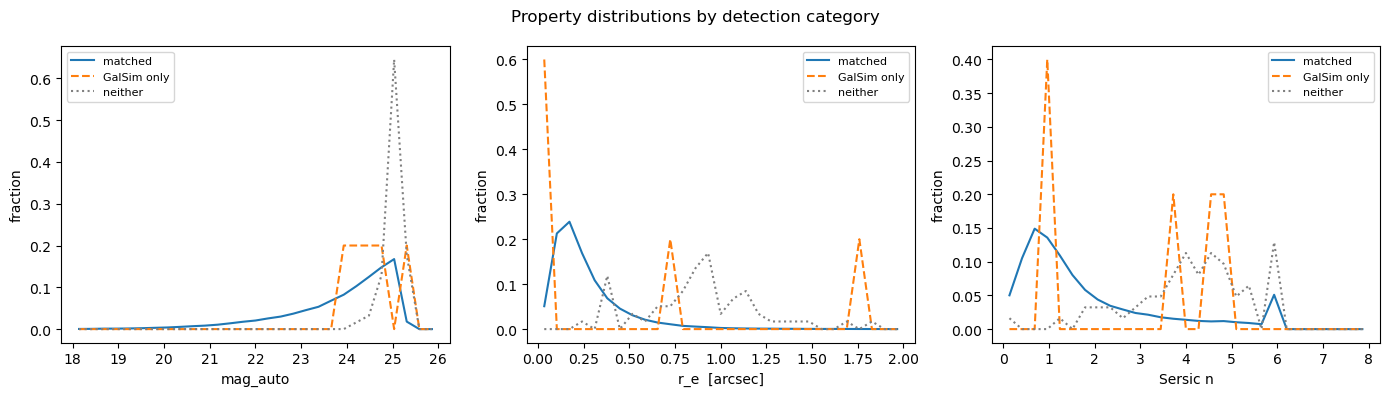

In [9]:
def collect_props(k_list):
    """
    Collect galaxy properties for a set of per-stamp local galaxy indices.

    Parameters
    ----------
    k_list : list of np.ndarray of int
        List of length n_stamps, where each element contains the local galaxy
        indices (k) within that stamp for the galaxies of interest.

    Returns
    -------
    dict
        Dictionary with keys:
        'mag'        : np.ndarray, AB magnitudes (mag_auto).
        'hlr'        : np.ndarray, half-light radii in arcsec.
        'sersic_n'   : np.ndarray, Sersic indices.
        'is_bulgefit' : np.ndarray of bool, True where a bulge+disk model was used.
    """
    mag, hlr, n_s, bulge = [], [], [], []
    for i, k_arr in enumerate(k_list):
        if len(k_arr) == 0:
            continue
        g_idx = stamp_offsets[i] + k_arr
        mag.append(mag_all[g_idx])
        hlr.append(hlr_all[g_idx])
        n_s.append(sersic_n_all[g_idx])
        bulge.append(is_bulgefit[g_idx])
    return {
        'mag':         np.concatenate(mag)   if mag   else np.array([]),
        'hlr':         np.concatenate(hlr)   if hlr   else np.array([]),
        'sersic_n':    np.concatenate(n_s)   if n_s   else np.array([]),
        'is_bulgefit': np.concatenate(bulge) if bulge else np.array([], dtype=bool),
    }


props_matched = collect_props(cat_gal_k)
props_gs_only = collect_props(gs_only_k_list)
props_bt_only = collect_props(bt_only_k_list)
props_neither = collect_props(neither_k_list)

# Summary table
print(f"{'Category':<20} {'N':>7}  {'mag (med)':>10}  {'hlr (med)':>10}  {'n (med)':>8}  {'bulge+disk':>10}")
print('-' * 72)
for label, p in [('matched',     props_matched),
                  ('GalSim only', props_gs_only),
                  ('BATSim only', props_bt_only),
                  ('neither',     props_neither)]:
    if len(p['mag']) == 0:
        print(f'{label:<20} {"0":>7}')
        continue
    print(f"{label:<20} {len(p['mag']):>7}  "
          f"{np.median(p['mag']):>10.2f}  "
          f"{np.median(p['hlr']):>10.4f}  "
          f"{np.median(p['sersic_n']):>8.2f}  "
          f"{p['is_bulgefit'].mean():>10.1%}")

# Property distribution plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Property distributions by detection category', fontsize=12)

plot_groups = [
    ('matched',     props_matched, 'C0',  '-'),
    ('GalSim only', props_gs_only, 'C1',  '--'),
    ('BATSim only', props_bt_only, 'C2',  '--'),
    ('neither',     props_neither, 'gray', ':'),
]

bins_mag = np.linspace(18, 26,  30)
bins_hlr = np.linspace(0,  2.0, 30)
bins_n   = np.linspace(0,  8,   30)

for ax, prop_key, bins, xlabel in [
    (axes[0], 'mag',      bins_mag, 'mag_auto'),
    (axes[1], 'hlr',      bins_hlr, 'r_e  [arcsec]'),
    (axes[2], 'sersic_n', bins_n,   'Sersic n'),
]:
    for label, p, color, ls in plot_groups:
        vals = p[prop_key]
        if len(vals) == 0:
            continue
        counts, edges = np.histogram(vals, bins=bins)
        centres = 0.5 * (edges[:-1] + edges[1:])
        ax.plot(centres, counts / counts.sum(), color=color, ls=ls, label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('fraction')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('detection_category_properties.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
def compute_bias_for_mask(galaxy_mask):
    """
    Compute jackknife multiplicative bias for a subset of galaxies.

    Applies a boolean mask over all galaxies (in stamp order) to select a
    subset, then accumulates the FPFS shear estimator sums per tile and
    passes them to jackknife_over_tiles.

    Parameters
    ----------
    galaxy_mask : np.ndarray of bool
        Boolean array of length equal to the total number of galaxies across
        all stamps (len(all_gal_inds)). True selects a galaxy for inclusion.

    Returns
    -------
    res_gs : dict or None
        Jackknife result dict for GalSim (see jackknife_over_tiles). None if
        no galaxies pass the mask or the total response is zero.
    res_bt : dict or None
        Jackknife result dict for BATSim. None under the same conditions.
    """
    E_gs, R_gs, E_bt, R_bt = [], [], [], []
    for i in range(len(gs_catalogs)):
        k_map    = cat_gal_k[i]
        det_mask = galaxy_mask[stamp_offsets[i] + k_map]
        for e_list, R_list, cat in [(E_gs, R_gs, gs_catalogs[i]),
                                     (E_bt, R_bt, bt_catalogs[i])]:
            e = (cat['fpfs_w'] * cat['fpfs_e1'])[det_mask]
            R = (cat['fpfs_dw_dg1'] * cat['fpfs_e1']
                 + cat['fpfs_w'] * cat['fpfs_de1_dg1'])[det_mask]
            e_list.append(e.sum())
            R_list.append(R.sum())
    if np.sum(R_gs) == 0 or np.sum(R_bt) == 0:
        return None, None
    return (jackknife_over_tiles(E_gs, R_gs, lens_shear),
            jackknife_over_tiles(E_bt, R_bt, lens_shear))


def run_binned_analysis(prop, bin_edges, label, base_mask=None):
    """
    Measure GalSim and BATSim multiplicative bias in bins of a galaxy property.

    Parameters
    ----------
    prop : np.ndarray
        Property values for all galaxies, in the same order as all_gal_inds.
    bin_edges : np.ndarray
        1D array of bin edges. Bins are half-open intervals [edge[i], edge[i+1]).
    label : str
        Label shown in the tqdm progress bar.
    base_mask : np.ndarray of bool or None, optional
        Additional boolean mask AND-ed with each bin mask before measuring.
        Useful for restricting to a sub-population (e.g. single-Sersic only).

    Returns
    -------
    dict
        Dictionary with keys:
        'centers'   : np.ndarray, bin centre values.
        'bin_edges' : np.ndarray, input bin edges.
        'm_gs'      : np.ndarray, GalSim multiplicative bias per bin.
        'm_gs_err'  : np.ndarray, jackknife error on m_gs.
        'm_bt'      : np.ndarray, BATSim multiplicative bias per bin.
        'm_bt_err'  : np.ndarray, jackknife error on m_bt.
        'n_gals'    : np.ndarray of int, number of galaxies per bin.
        'dm'        : np.ndarray, m_bt - m_gs per bin.
        'dm_err'    : np.ndarray, propagated error on dm.
    """
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    n_bins  = len(centers)
    out = dict(
        centers=centers, bin_edges=bin_edges,
        m_gs=np.full(n_bins, np.nan), m_gs_err=np.full(n_bins, np.nan),
        m_bt=np.full(n_bins, np.nan), m_bt_err=np.full(n_bins, np.nan),
        n_gals=np.zeros(n_bins, dtype=int),
    )
    for b in tqdm(range(n_bins), desc=label):
        mask = (prop >= bin_edges[b]) & (prop < bin_edges[b + 1])
        if base_mask is not None:
            mask &= base_mask
        out['n_gals'][b] = mask.sum()
        if out['n_gals'][b] < 100:
            continue
        res_gs, res_bt = compute_bias_for_mask(mask)
        if res_gs is None:
            continue
        out['m_gs'][b], out['m_gs_err'][b] = res_gs['m'], res_gs['m_err']
        out['m_bt'][b], out['m_bt_err'][b] = res_bt['m'], res_bt['m_err']
    out['dm']     = out['m_bt'] - out['m_gs']
    out['dm_err'] = np.sqrt(out['m_gs_err'] ** 2 + out['m_bt_err'] ** 2)
    return out

In [11]:
# Full-sample reference bias (no cuts)
E_gs, R_gs, E_bt, R_bt = [], [], [], []
for i in range(len(gs_catalogs)):
    for e_list, R_list, cat in [(E_gs, R_gs, gs_catalogs[i]),
                                 (E_bt, R_bt, bt_catalogs[i])]:
        e = cat['fpfs_w'] * cat['fpfs_e1']
        R = cat['fpfs_dw_dg1'] * cat['fpfs_e1'] + cat['fpfs_w'] * cat['fpfs_de1_dg1']
        e_list.append(e.sum())
        R_list.append(R.sum())

res_full_gs = jackknife_over_tiles(E_gs, R_gs, lens_shear)
res_full_bt = jackknife_over_tiles(E_bt, R_bt, lens_shear)

print(f'True g1 = {lens_shear}')
print(f'GalSim  g1 = {res_full_gs["g1"]:.6f} ± {res_full_gs["g1_err"]:.6f}  |  m = {res_full_gs["m"]:.4e} ± {res_full_gs["m_err"]:.4e}')
print(f'BATSim  g1 = {res_full_bt["g1"]:.6f} ± {res_full_bt["g1_err"]:.6f}  |  m = {res_full_bt["m"]:.4e} ± {res_full_bt["m_err"]:.4e}')

True g1 = 0.02
GalSim  g1 = 0.019994 ± 0.000014  |  m = -2.9320e-04 ± 6.9203e-04
BATSim  g1 = 0.020084 ± 0.000014  |  m = 4.1996e-03 ± 6.9701e-04


In [16]:
res_mag = run_binned_analysis(
    mag_all, np.array([18, 20, 21, 22, 23, 24, 25, 25.3]), 'magnitude'
)

res_n = run_binned_analysis(
    sersic_n_all, np.array([0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0]),
    'Sersic n', base_mask=~is_bulgefit
)

res_hlr = run_binned_analysis(
    hlr_all, np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.2, 2.0]),
    'half-light radius'
)

half-light radius: 100%|██████████| 8/8 [00:00<00:00, 23.42it/s]


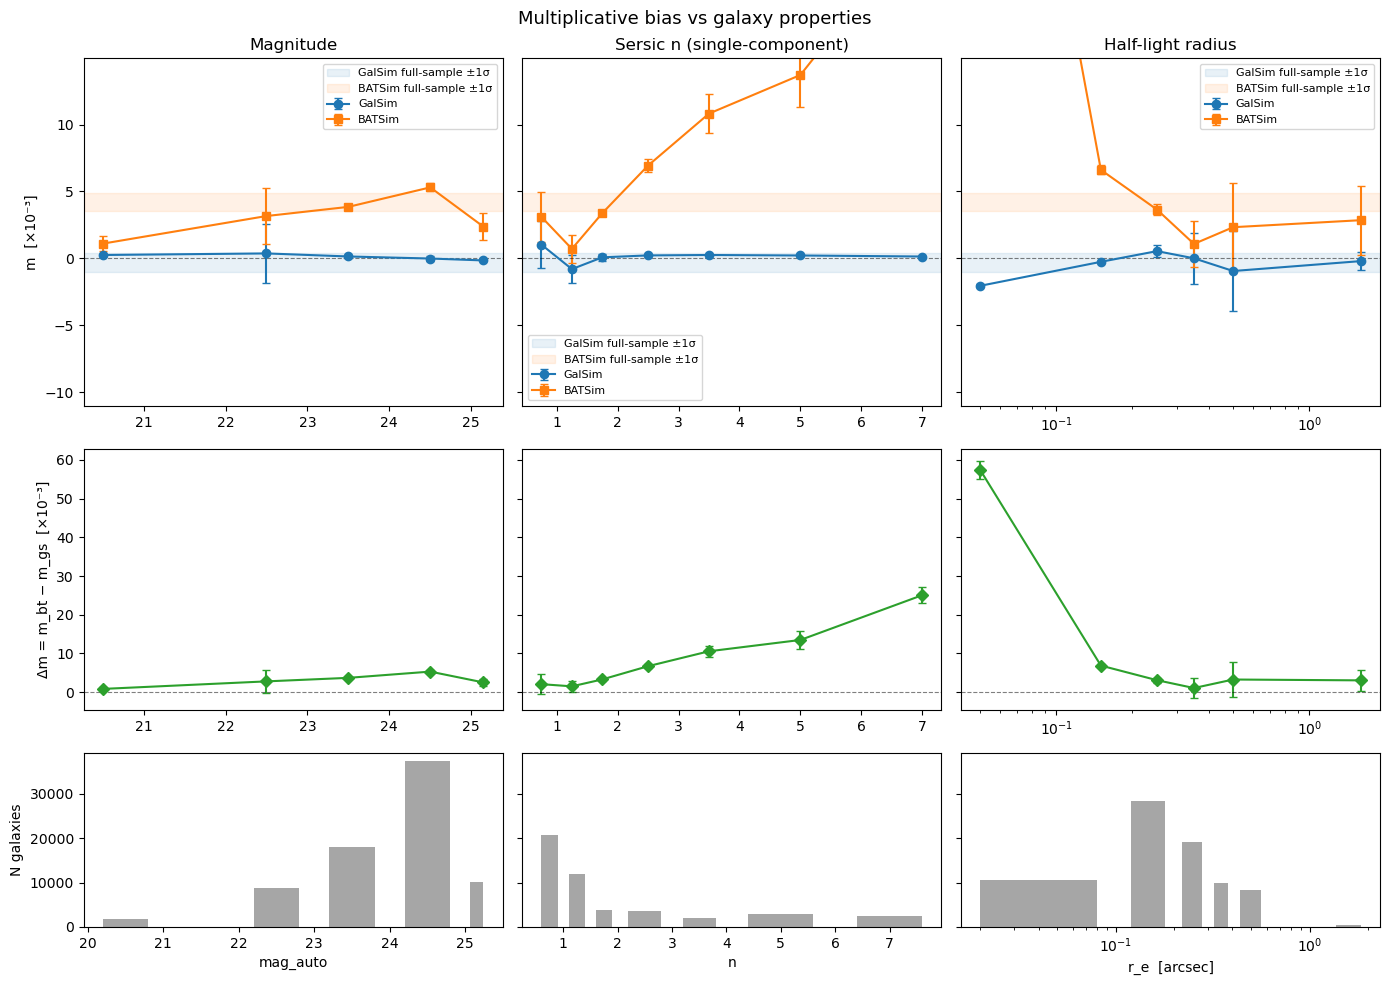

In [17]:
def get_valid(res, ref_err, max_err_factor=5):
    """
    Build a boolean mask selecting bins with reliable bias estimates.

    Filters out bins where the jackknife error is more than max_err_factor
    times the full-sample reference error, which typically indicates too few
    galaxies for a stable estimate.

    Parameters
    ----------
    res : dict
        Output dict from run_binned_analysis.
    ref_err : float
        Full-sample jackknife error used as the reference scale.
    max_err_factor : float, optional
        Maximum allowed ratio of bin error to ref_err. Default is 5.

    Returns
    -------
    np.ndarray of bool
        True for bins that are not NaN and have errors within the threshold.
    """
    return (
        ~np.isnan(res['m_gs'])
        & (res['m_gs_err'] < max_err_factor * ref_err)
        & (res['m_bt_err'] < max_err_factor * ref_err)
    )


def plot_selection_bias_summary(results_list, titles, xlabels, log_x_flags,
                                res_full_gs, res_full_bt, save_path=None):
    """
    Plot multiplicative bias vs galaxy property for multiple properties.

    Produces a 3-row × N-column figure where each column corresponds to one
    galaxy property. Row 0 shows m_gs and m_bt with full-sample reference
    bands, row 1 shows the difference Δm = m_bt - m_gs, and row 2 shows
    the number of galaxies per bin.

    Parameters
    ----------
    results_list : list of dict
        List of output dicts from run_binned_analysis, one per property.
    titles : list of str
        Column titles, one per property.
    xlabels : list of str
        x-axis labels, one per property.
    log_x_flags : list of bool
        If True, use a log x-axis for that column.
    res_full_gs : dict
        Full-sample jackknife result for GalSim (used for reference bands).
    res_full_bt : dict
        Full-sample jackknife result for BATSim (used for reference bands).
    save_path : str or None, optional
        If provided, save the figure to this path. Default is None.

    Returns
    -------
    None
    """
    fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharey='row',
                             gridspec_kw={'height_ratios': [2, 1.5, 1]})
    fig.suptitle('Multiplicative bias vs galaxy properties', fontsize=13)

    ref_lo = min((res_full_gs['m'] - 3 * res_full_gs['m_err']) * 1e3,
                 (res_full_bt['m'] - 3 * res_full_bt['m_err']) * 1e3)
    ref_hi = max((res_full_gs['m'] + 3 * res_full_gs['m_err']) * 1e3,
                 (res_full_bt['m'] + 3 * res_full_bt['m_err']) * 1e3)
    pad = abs(ref_hi - ref_lo)

    for col, (res, title, xlabel, log_x) in enumerate(
        zip(results_list, titles, xlabels, log_x_flags)
    ):
        valid  = get_valid(res, res_full_gs['m_err'])
        x      = res['centers'][valid]
        widths = np.diff(res['bin_edges'])[valid] * 0.6

        ax = axes[0, col]
        ax.axhspan((res_full_gs['m'] - res_full_gs['m_err']) * 1e3,
                   (res_full_gs['m'] + res_full_gs['m_err']) * 1e3,
                   alpha=0.1, color='C0', label='GalSim full-sample ±1σ')
        ax.axhspan((res_full_bt['m'] - res_full_bt['m_err']) * 1e3,
                   (res_full_bt['m'] + res_full_bt['m_err']) * 1e3,
                   alpha=0.1, color='C1', label='BATSim full-sample ±1σ')
        ax.errorbar(x, res['m_gs'][valid] * 1e3, yerr=res['m_gs_err'][valid] * 1e3,
                    fmt='o-', capsize=3, label='GalSim')
        ax.errorbar(x, res['m_bt'][valid] * 1e3, yerr=res['m_bt_err'][valid] * 1e3,
                    fmt='s-', capsize=3, label='BATSim')
        ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
        ax.set_title(title)
        ax.set_ylim(ref_lo - pad, ref_hi + pad)
        if col == 0:
            ax.set_ylabel('m  [×10⁻³]')
        ax.legend(fontsize=8)

        ax2 = axes[1, col]
        ax2.errorbar(x, res['dm'][valid] * 1e3, yerr=res['dm_err'][valid] * 1e3,
                     fmt='D-', color='C2', capsize=3)
        ax2.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
        if col == 0:
            ax2.set_ylabel('Δm = m_bt − m_gs  [×10⁻³]')

        ax3 = axes[2, col]
        ax3.bar(x, res['n_gals'][valid], width=widths, color='gray', alpha=0.7)
        ax3.set_xlabel(xlabel)
        if col == 0:
            ax3.set_ylabel('N galaxies')

        if log_x:
            for ax_ in axes[:, col]:
                ax_.set_xscale('log')

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_selection_bias_summary(
    results_list = [res_mag,    res_n,                         res_hlr],
    titles       = ['Magnitude', 'Sersic n (single-component)', 'Half-light radius'],
    xlabels      = ['mag_auto',  'n',                           'r_e  [arcsec]'],
    log_x_flags  = [False,       False,                         True],
    res_full_gs  = res_full_gs,
    res_full_bt  = res_full_bt,
    save_path    = 'selection_bias_summary.png',
)

## Image generation timing\n\nTimes GalSim and BATSim rendering a representative sample of galaxies sequentially (no multiprocessing) to get a clean per-galaxy comparison."

In [14]:
from time import perf_counter

N_TIMING = 200   # number of galaxies; increase for more stable estimates

# Load timing sample — draw evenly from the full magnitude range
timing_inds    = np.linspace(0, len(all_gal_inds) - 1, N_TIMING, dtype=int)
timing_cosmos  = all_gal_inds[timing_inds]
timing_records = cosmos.getParametricRecord(index=timing_cosmos)
timing_galaxies = cosmos.makeGalaxy(index=timing_cosmos, gal_type='parametric')
fluxes = 10 ** ((30 - timing_records['mag_auto']) / 2.5)
timing_galaxies = [gal.withFlux(f) for gal, f in zip(timing_galaxies, fluxes)]

LensTransform = batsim.LensTransform(gamma1=lens_shear, gamma2=0, kappa=0)

# Time GalSim — one galaxy, one rotation, no noise
gs_times = []
for gal in tqdm(timing_galaxies, desc='GalSim'):
    t0 = perf_counter()
    conv = galsim.Convolve([gal.shear(g1=lens_shear), psf])
    conv.drawImage(nx=nn, ny=nn, scale=scale, method='auto')
    gs_times.append(perf_counter() - t0)

# Time BATSim — same galaxy, same stamp size
bt_times = []
for gal in tqdm(timing_galaxies, desc='BATSim'):
    t0 = perf_counter()
    batsim.simulate_galaxy(
        gal_obj=gal,
        ngrid=nn,
        pix_scale=scale,
        transform_obj=LensTransform,
        psf_obj=psf,
        maximum_num_grids=4096 * 4,
        draw_method='auto',
    )
    bt_times.append(perf_counter() - t0)

gs_times = np.array(gs_times)
bt_times = np.array(bt_times)

# Summary
n_images = len(all_gal_inds) * n_rot
print(f"\n{'':25} {'GalSim':>12} {'BATSim':>12} {'BT / GS':>10}")
print('-' * 62)
for label, gs, bt in [
    ('Mean per galaxy (ms)',  gs_times.mean()   * 1e3, bt_times.mean()   * 1e3),
    ('Median per galaxy (ms)', np.median(gs_times) * 1e3, np.median(bt_times) * 1e3),
    ('Std (ms)',               gs_times.std()    * 1e3, bt_times.std()    * 1e3),
]:
    ratio = bt / gs if label != 'Std (ms)' else float('nan')
    ratio_str = f'{ratio:.2f}x' if np.isfinite(ratio) else ''
    print(f'{label:<25} {gs:>12.2f} {bt:>12.2f} {ratio_str:>10}')

print()
print(f'Estimated full-catalog time ({n_images} images, sequential):')
print(f'  GalSim : {gs_times.mean() * n_images / 3600:.2f} hours')
print(f'  BATSim : {bt_times.mean() * n_images / 3600:.2f} hours')

BATSim: 100%|██████████| 200/200 [00:26<00:00,  7.68it/s]


                                GalSim       BATSim    BT / GS
--------------------------------------------------------------
Mean per galaxy (ms)             11.69       129.62     11.09x
Median per galaxy (ms)            1.93        33.66     17.45x
Std (ms)                         57.93       327.61           

Estimated full-catalog time (325996 images, sequential):
  GalSim : 1.06 hours
  BATSim : 11.74 hours


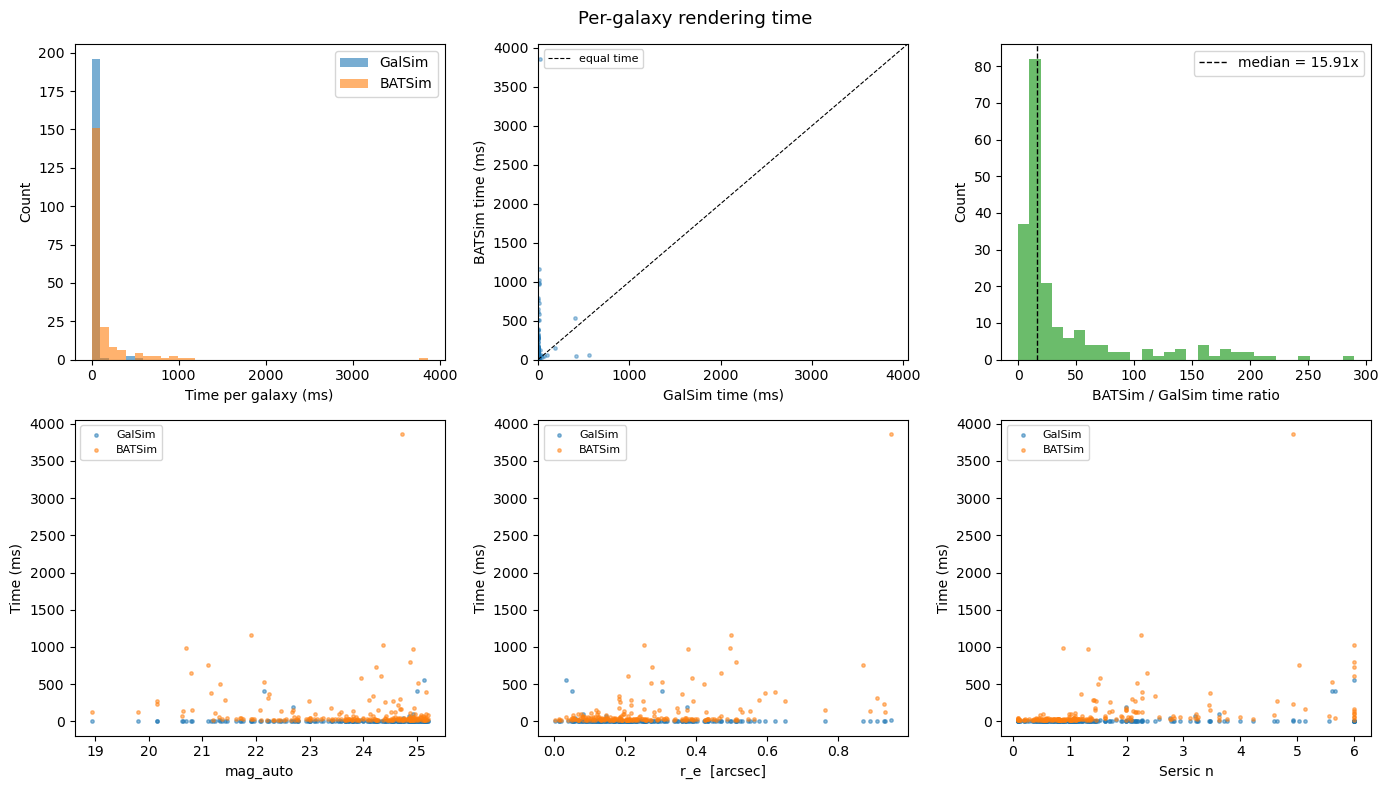

In [15]:
timing_mag     = timing_records['mag_auto']
timing_hlr     = all_records['hlr'][timing_inds, 0]
timing_sersic_n = all_records['sersicfit'][timing_inds, 2]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Per-galaxy rendering time', fontsize=13)

# Row 0: timing distributions
ax = axes[0, 0]
bins = np.linspace(0, max(gs_times.max(), bt_times.max()) * 1e3, 40)
ax.hist(gs_times * 1e3, bins=bins, alpha=0.6, label='GalSim')
ax.hist(bt_times * 1e3, bins=bins, alpha=0.6, label='BATSim')
ax.set_xlabel('Time per galaxy (ms)')
ax.set_ylabel('Count')
ax.legend()

ax2 = axes[0, 1]
ax2.scatter(gs_times * 1e3, bt_times * 1e3, s=6, alpha=0.4)
lim = max(gs_times.max(), bt_times.max()) * 1e3 * 1.05
ax2.plot([0, lim], [0, lim], 'k--', lw=0.8, label='equal time')
ax2.set_xlabel('GalSim time (ms)')
ax2.set_ylabel('BATSim time (ms)')
ax2.set_xlim(0, lim)
ax2.set_ylim(0, lim)
ax2.legend(fontsize=8)

ax3 = axes[0, 2]
ratio = bt_times / gs_times
ax3.hist(ratio, bins=30, color='C2', alpha=0.7)
ax3.axvline(np.median(ratio), color='k', ls='--', lw=1, label=f'median = {np.median(ratio):.2f}x')
ax3.set_xlabel('BATSim / GalSim time ratio')
ax3.set_ylabel('Count')
ax3.legend()

# Row 1: timing vs galaxy properties
for ax, prop, xlabel, log_x in [
    (axes[1, 0], timing_mag,      'mag_auto',     False),
    (axes[1, 1], timing_hlr,      'r_e  [arcsec]', False),
    (axes[1, 2], timing_sersic_n, 'Sersic n',     False),
]:
    ax.scatter(prop, gs_times * 1e3, s=6, alpha=0.5, label='GalSim', color='C0')
    ax.scatter(prop, bt_times * 1e3, s=6, alpha=0.5, label='BATSim', color='C1')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Time (ms)')
    ax.legend(fontsize=8)
    if log_x:
        ax.set_xscale('log')

plt.tight_layout()
plt.savefig('timing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()